In [1]:
import os.path as op
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
short_color=np.array([255,0,0])/255.0
long_color=np.array([0,0,255])/255.0

In [16]:
all_tf={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
tf_time=None
tf_freqs=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']

In [17]:
t_stim_idx=np.where((tf_time>=-1.5) & (tf_time<=.5))[0]
t_resp_idx=np.where((tf_time>=-.5) & (tf_time<=1.5))[0]
tf_stim_time=tf_time[t_stim_idx]
tf_resp_time=tf_time[t_resp_idx]
base_idx=np.where((tf_time>=-.75) & (tf_time<=-.25))[0]

f_idx=(tf_freqs>5) & (tf_freqs<100)
tf_freqs=tf_freqs[f_idx]

tf_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            base_tf=np.mean(all_tf[hemi]['STIM']['LONG'][s_idx][f_idx][:,base_idx],axis=-1)
            for condition in ['SHORT','LONG']:
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)
        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            base_tf=np.mean(all_tf[hemi]['STIM']['LONG'][s_idx][f_idx][:,base_idx],axis=-1)
            for condition in ['SHORT','LONG']:
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                tf_bc[group][epoch][condition][hemi]=np.array(tf_bc[group][epoch][condition][hemi])
                
n_td=tf_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=tf_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


# TD: SHORT-LONG

stat_fun(H1): min=-0.000003 max=37.816849
Running initial clustering …
Using 379 thresholds from 0.00 to 37.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000007 max=20.713758
Running initial clustering …
Using 208 thresholds from 0.00 to 20.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

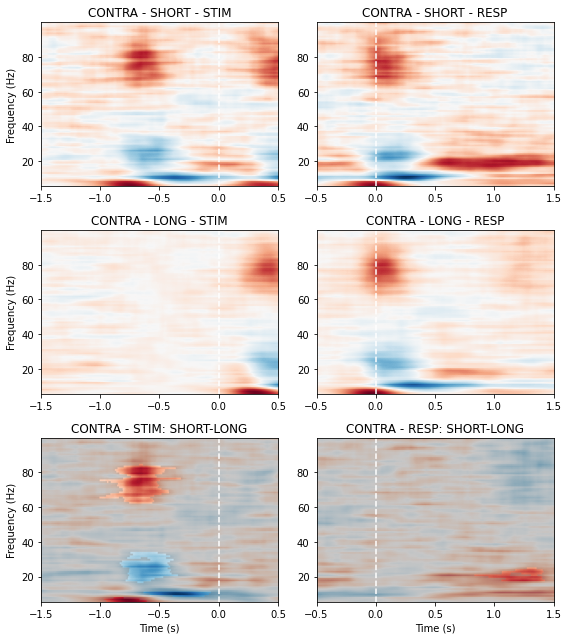

In [20]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(8,9))
contra_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['contra'],axis=0)
contra_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['contra'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
]))

ax=plt.subplot(3,2,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,2,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,2,3)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,2,4)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

contra_stim_diff=contra_stim_short-contra_stim_long
contra_resp_diff=contra_resp_short-contra_resp_long

all_diff=np.vstack([contra_stim_diff[:], contra_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,2,5)

data = [tf_bc['TD']['STIM']['SHORT']['contra'], tf_bc['TD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(contra_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - STIM: SHORT-LONG')

ax=plt.subplot(3,2,6)

data = [tf_bc['TD']['RESP']['SHORT']['contra'], tf_bc['TD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(contra_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - RESP: SHORT-LONG')

plt.tight_layout()

In [29]:
all_beta_power={
    group: {
        hemi: {        
            epo_type: {
                condition_name: [] for condition_name in condition_names
            } for epo_type in epoch_types
        } for hemi in ['ipsi','contra']
    } for group in ['TD','ASD']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            data = np.load(fname, allow_pickle=True)
            subj_beta_power = data['all_beta_pow'].item()
            for hemi in ['ipsi','contra']:
                for epo_type in epoch_types:
                    for condition_name in condition_names:
                        all_beta_power[group][hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
            power_time = data['time']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            data = np.load(fname, allow_pickle=True)
            subj_beta_power = data['all_beta_pow'].item()
            for hemi in ['ipsi','contra']:
                for epo_type in epoch_types:
                    for condition_name in condition_names:
                        all_beta_power[group][hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
            power_time = data['time']

In [36]:
t_stim_idx=np.where((power_time>=-1.5) & (power_time<=0.5))[0]
t_resp_idx=np.where((power_time>=-.5) & (power_time<=1.5))[0]
base_idx=np.where((power_time>=-.75) & (power_time<=-.25))[0]
        
beta_pow_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

s_idx=0

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for subject_id, group in subjects:
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            for hemi in ['contra','ipsi']:
                base_pow=np.mean(all_beta_power[group][hemi]['STIM']['LONG'][s_idx][base_idx])
                for condition in ['SHORT','LONG']:
                    b_pow_stim=all_beta_power[group][hemi]['STIM'][condition][s_idx][t_stim_idx]
                    b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                    b_pow_resp=all_beta_power[group][hemi]['RESP'][condition][s_idx][t_resp_idx]
                    b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                    beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                    beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
            s_idx+=1

        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for subject_id, group in subjects:
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            for hemi in ['contra','ipsi']:
                base_pow=np.mean(all_beta_power[group][hemi]['STIM']['LONG'][s_idx][base_idx])
                for condition in ['SHORT','LONG']:
                    b_pow_stim=all_beta_power[group][hemi]['STIM'][condition][s_idx][t_stim_idx]
                    b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                    b_pow_resp=all_beta_power[group][hemi]['RESP'][condition][s_idx][t_resp_idx]
                    b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                    beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                    beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
            s_idx+=1
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                beta_pow_bc[group][epoch][condition][hemi]=np.array(beta_pow_bc[group][epoch][condition][hemi])
                
n_td=beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=beta_pow_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=0


stat_fun(H1): min=-7.204543 max=4.572067
Running initial clustering …
Using 721 thresholds from 0.00 to 7.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.095868 max=6.952291
Running initial clustering …
Using 696 thresholds from 0.00 to 6.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

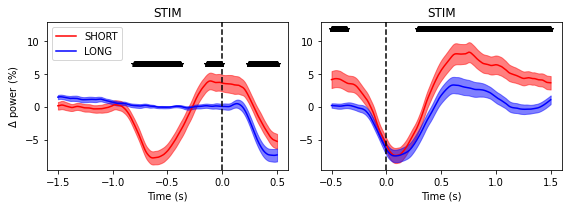

In [38]:
plt.figure(figsize=(8,3))

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

# Define all subplot conditions
conditions = [
    ('TD', 'STIM', 'contra', 'TD - STIM - contra', 1),
    ('TD', 'RESP', 'contra', 'TD - RESP - contra', 2)
]

axes = []
ax = plt.subplot(1, 2, 1)

# Plot SHORT
m_pow = np.mean(beta_pow_bc['TD']['STIM']['SHORT']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['STIM']['SHORT']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['STIM']['SHORT']['contra'].shape[0])
ax.plot(power_time[t_stim_idx], m_pow, label='SHORT', color=short_color)
ax.fill_between(power_time[t_stim_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

# Plot LONG
m_pow = np.mean(beta_pow_bc['TD']['STIM']['LONG']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['STIM']['LONG']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['STIM']['LONG']['contra'].shape[0])
ax.plot(power_time[t_stim_idx], m_pow, label='LONG', color=long_color)
ax.fill_between(power_time[t_stim_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

# Paired t-test
data = [beta_pow_bc['TD']['STIM']['SHORT']['contra'], beta_pow_bc['TD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    stat_fun=paired_t,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0
)

# Plot significant clusters
yl = ax.get_ylim()
py = yl[1] + .1 * (yl[1] - 0)
for p_idx, p_val in enumerate(cluster_p_values):
    if p_val < 0.05:
        ax.plot(power_time[t_stim_idx][p_idx], py, 'k*')

# Formatting
ax.axvline(0, color='k', linestyle='--')
ax.set_title('STIM')

ax.legend()
ax.set_ylabel(r'$\Delta$ power (%)')

ax.set_xlabel('Time (s)')

axes.append(ax)

ax = plt.subplot(1, 2, 2)

# Plot SHORT
m_pow = np.mean(beta_pow_bc['TD']['RESP']['SHORT']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['RESP']['SHORT']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['RESP']['SHORT']['contra'].shape[0])
ax.plot(power_time[t_resp_idx], m_pow, label='SHORT', color=short_color)
ax.fill_between(power_time[t_resp_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

# Plot LONG
m_pow = np.mean(beta_pow_bc['TD']['RESP']['LONG']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['RESP']['LONG']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0])
ax.plot(power_time[t_resp_idx], m_pow, label='LONG', color=long_color)
ax.fill_between(power_time[t_resp_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

# Paired t-test
data = [beta_pow_bc['TD']['RESP']['SHORT']['contra'], beta_pow_bc['TD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    stat_fun=paired_t,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0
)

# Plot significant clusters
yl = ax.get_ylim()
py = yl[1] + .1 * (yl[1] - 0)
for p_idx, p_val in enumerate(cluster_p_values):
    if p_val < 0.05:
        ax.plot(power_time[t_resp_idx][p_idx], py, 'k*')

# Formatting
ax.axvline(0, color='k', linestyle='--')
ax.set_title('STIM')

ax.set_xlabel('Time (s)')
    
axes.append(ax)

# Equalize y-limits across all subplots
ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
